# Notebook 07: Size interaction (SQ3)

Research Sub-Question 3: Does the cross-population directional (a)symmetry depend on source training-set size?

Evaluates whether the direction gap (N2K vs K2N) changes across Kermany source sizes (50, 100, 190). A flat trend indicates that directional asymmetry is an inherent dataset property rather than a data-quantity artifact.

## 1. Setup and load predictions

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

REPO_ON_DRIVE = "/content/drive/MyDrive/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import metrics as MET
from src import stats as ST
from src import results as RES

for mod in (config, MET, ST, RES):
    importlib.reload(mod)

config.ensure_output_dirs()
config.set_plot_style()


Mounted at /content/drive


In [ ]:
meta, arrays = RES.load_predictions(config.RESULTS_DIR / "predictions")
print(f"Loaded {len(meta)} prediction runs from disk.")
print("\nRun breakdown by direction and source training size:")
print(meta.groupby(["direction", "size"]).size().to_string())


Loaded 48 prediction runs from disk.

Run breakdown by direction and source training size:
direction  size
K2N        50       6
           100      6
           190      6
N2K        190     30


## 2. Evaluate K2N Performance as a Function of Source Size

In [ ]:
ece_metric_fn = lambda a, b: MET.expected_calibration_error(a, b, config.ECE_N_BINS)

def compute_ci_for_group(direction, metric_fn, size=None):
    """Utility to extract pooled predictions and run bootstrap CI estimation."""
    y_true, y_prob = RES.pool_predictions(meta, arrays, direction=direction, size=size)
    return ST.bootstrap_ci(
        y_true,
        y_prob,
        metric_fn,
        n_boot=config.BOOTSTRAP_N,
        ci=config.BOOTSTRAP_CI,
        seed=config.SEED
    )

table_rows = []

# Evaluate K2N across sizes (50, 100, 190)
for size in config.MATCHED_SIZES:
    auroc_res = compute_ci_for_group("K2N", MET.auroc, size=size)
    ece_res = compute_ci_for_group("K2N", ece_metric_fn, size=size)

    table_rows.append({
        "direction": "K2N",
        "size": size,
        "auroc": round(auroc_res[0], 3),
        "auroc_lo": round(auroc_res[1], 3),
        "auroc_hi": round(auroc_res[2], 3),
        "ece": round(ece_res[0], 3),
        "ece_lo": round(ece_res[1], 3),
        "ece_hi": round(ece_res[2], 3)
    })

# Add baseline N2K (Size = 190)
n2k_auroc_res = compute_ci_for_group("N2K", MET.auroc)
n2k_ece_res = compute_ci_for_group("N2K", ece_metric_fn)

table_rows.append({
    "direction": "N2K",
    "size": 190,
    "auroc": round(n2k_auroc_res[0], 3),
    "auroc_lo": round(n2k_auroc_res[1], 3),
    "auroc_hi": round(n2k_auroc_res[2], 3),
    "ece": round(n2k_ece_res[0], 3),
    "ece_lo": round(n2k_ece_res[1], 3),
    "ece_hi": round(n2k_ece_res[2], 3)
})

size_table = pd.DataFrame(table_rows)
print("\n--- Discrimination and Calibration by Source Size (95% Bootstrap CI) ---")
print(size_table.to_string(index=False))

csv_out_path = config.RESULTS_DIR / "07_size_interaction.csv"
size_table.to_csv(csv_out_path, index=False)
print(f"Saved summary table to {csv_out_path.name}")



--- Discrimination and Calibration by Source Size (95% Bootstrap CI) ---
direction  size  auroc  auroc_lo  auroc_hi   ece  ece_lo  ece_hi
      K2N    50  0.597     0.511     0.678 0.228   0.176   0.306
      K2N   100  0.633     0.548     0.712 0.301   0.252   0.375
      K2N   190  0.638     0.552     0.717 0.257   0.209   0.337
      N2K   190  0.662     0.654     0.669 0.143   0.140   0.147
Saved summary table to 07_size_interaction.csv


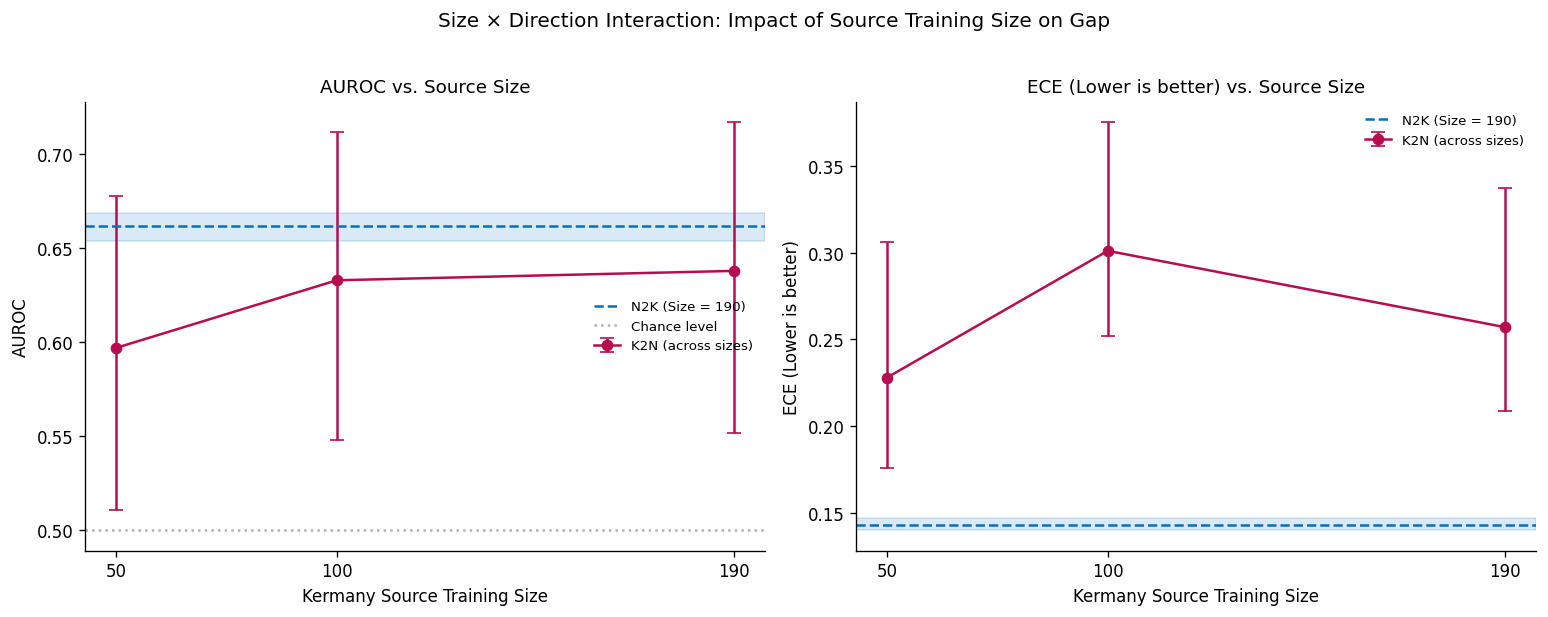

Saved figure to 07_size_interaction.png


In [ ]:
# Visualization: Metric vs Source Size
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

k2n_df = size_table[size_table.direction == "K2N"].sort_values("size")
n2k_row = size_table[size_table.direction == "N2K"].iloc[0]

metrics_config = [
    (axes[0], "auroc", "auroc_lo", "auroc_hi", "AUROC"),
    (axes[1], "ece", "ece_lo", "ece_hi", "ECE (Lower is better)")
]

for ax, metric, metric_lo, metric_hi, label in metrics_config:
    y_err = [k2n_df[metric] - k2n_df[metric_lo], k2n_df[metric_hi] - k2n_df[metric]]

    # Plot K2N trajectory across sizes
    ax.errorbar(
        k2n_df["size"],
        k2n_df[metric],
        yerr=y_err,
        marker="o",
        capsize=4,
        color=config.BRAND["C1"],
        label="K2N (across sizes)"
    )

    # Plot N2K baseline band (Full size = 190)
    ax.axhspan(n2k_row[metric_lo], n2k_row[metric_hi], alpha=0.15, color=config.BRAND["C3"])
    ax.axhline(n2k_row[metric], color=config.BRAND["C3"], linestyle="--", label="N2K (Size = 190)")

    if metric == "auroc":
        ax.axhline(0.5, color="grey", linestyle=":", alpha=0.6, label="Chance level")

    ax.set_xlabel("Kermany Source Training Size")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs. Source Size")
    ax.set_xticks(config.MATCHED_SIZES)
    ax.legend(fontsize=8)

fig.suptitle("Size × Direction Interaction: Impact of Source Training Size on Gap", y=1.02)
fig.tight_layout()

fig_out_path = config.FIGURES_DIR / "07_size_interaction.png"
fig.savefig(fig_out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved figure to {fig_out_path.name}")


## 3. Size Interaction Test: Evaluating Gap Variation Across Sizes

In [ ]:
print("\n--- Size Interaction Test (Comparing Direction Gap at Size 190 vs Size 50) ---")

for metric_name, metric_fn in [("AUROC", MET.auroc), ("ECE", ece_metric_fn)]:

    def compute_direction_gap(size, m_fn=metric_fn):
        """Computes bootstrap vector difference for N2K - K2N(size)."""
        yt_k2n, yp_k2n = RES.pool_predictions(meta, arrays, direction="K2N", size=size)
        yt_n2k, yp_n2k = RES.pool_predictions(meta, arrays, direction="N2K")

        _, _, _, boot_k2n = ST.bootstrap_ci(yt_k2n, yp_k2n, m_fn, n_boot=config.BOOTSTRAP_N, seed=config.SEED)
        _, _, _, boot_n2k = ST.bootstrap_ci(yt_n2k, yp_n2k, m_fn, n_boot=config.BOOTSTRAP_N, seed=config.SEED)

        n_samples = min(len(boot_k2n), len(boot_n2k))
        return boot_n2k[:n_samples] - boot_k2n[:n_samples]

    gap_50 = compute_direction_gap(50)
    gap_190 = compute_direction_gap(190)

    n_common = min(len(gap_50), len(gap_190))
    interaction_dist = gap_190[:n_common] - gap_50[:n_common]

    ci_lo, ci_hi = np.percentile(interaction_dist, [2.5, 97.5])
    mean_interaction = interaction_dist.mean()

    status_text = (
        "CI excludes 0: reliable size interaction present at the 95% level"
        if (ci_lo > 0 or ci_hi < 0)
        else "CI includes 0: no reliable size interaction detected"
    )

    print(f"Metric: {metric_name}")
    print(f"  Direction Gap at Size  50 (N2K - K2N): {gap_50.mean():+.3f}")
    print(f"  Direction Gap at Size 190 (N2K - K2N): {gap_190.mean():+.3f}")
    print(f"  Interaction (Gap 190 - Gap 50):       {mean_interaction:+.3f}  95% CI [{ci_lo:+.3f}, {ci_hi:+.3f}]")
    print(f"  Conclusion -> {status_text}\n")



--- Size Interaction Test (Comparing Direction Gap at Size 190 vs Size 50) ---
Metric: AUROC
  Direction Gap at Size  50 (N2K - K2N): +0.065
  Direction Gap at Size 190 (N2K - K2N): +0.025
  Interaction (Gap 190 - Gap 50):       -0.041  95% CI [-0.102, +0.020]
  Conclusion -> CI includes 0: no reliable size interaction detected

Metric: ECE
  Direction Gap at Size  50 (N2K - K2N): -0.096
  Direction Gap at Size 190 (N2K - K2N): -0.128
  Interaction (Gap 190 - Gap 50):       -0.032  95% CI [-0.093, +0.034]
  Conclusion -> CI includes 0: no reliable size interaction detected



**Next:** notebook 08 (significance).